In [1]:
import pybamm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy import constants
from pybamm import Scalar

current_directory = os.getcwd()

options = {"thermal": "lumped"}

For NMC811/Graphite-Si lithium ion cell

In [2]:
model = pybamm.lithium_ion.DFN(options=options)

parameter_values = pybamm.ParameterValues("OKane2022")

In [3]:
# Cell design specific parameters to be updated using values from the cell design tool

parameter_values.update({
                        "Negative electrode thickness [m]": 8.52e-05,
                        "Negative electrode porosity": 0.25,
                        "Negative electrode active material volume fraction": 0.75,
                        
                        
                        "Separator thickness [m]": 1.2e-5,
                        "Separator porosity": 0.47,
                        
                        "Positive electrode thickness [m]": 7.56e-5,
                        "Positive electrode porosity": 0.335,
                        "Positive electrode active material volume fraction": 0.665,
                        
                        #use the lesser values of (cathode, anode)
                        "Electrode height [m]": 65e-3, 
                        "Electrode width [m]": 1.58,
                         
                        "Nominal cell capacity [A.h]": 5,
                        "Current function [A]": 5.0,
                        "Contact resistance [Ohm]": 0.0,
                        "Cell cooling surface area [m2]": 0.00531, # added this
                        "Cell volume [m3]": 2.42e-05,
                        
                        },check_already_exists=False)

parameter_values.update({
                        
                        "Maximum concentration in negative electrode [mol.m-3]": 33133.0, #to be calculated from mAh/g
                        "Maximum concentration in positive electrode [mol.m-3]": 63104.0, #to be calculated from mAh/g
                        # leave it to default values for now
                        })

In [4]:
C_rates_in = 1

In [5]:
sim = pybamm.Simulation(model=model, parameter_values=parameter_values, C_rate=C_rates_in)
sim.solve([0, 4000/C_rates_in])
sim.plot()

/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/src/pybamm/simulation.py:122: UserWarning: The default solver changed to IDAKLUSolver after the v25.4.0. release. You can swap back to the previous default by using `pybamm.CasadiSolver()` instead.
  self._solver = solver or self._model.default_solver


interactive(children=(FloatSlider(value=0.0, description='t', max=3579.8825839424335, step=35.79882583942433),…

In [7]:
sim.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=3579.8825839424335, step=35.79882583942433),…

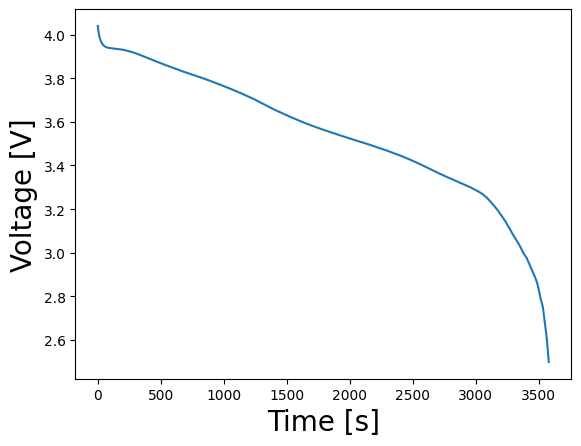

Text(0, 0.5, 'Voltage [V]')

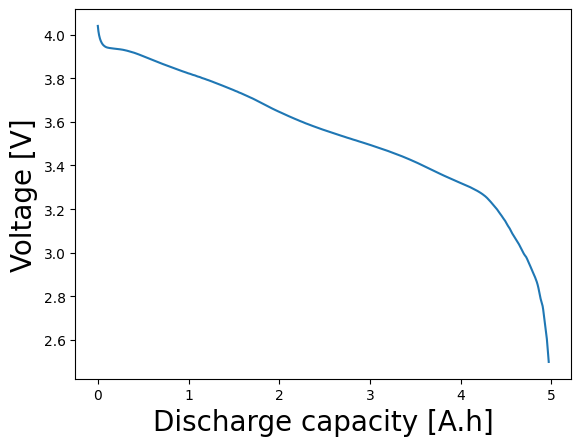

In [6]:
t1 = sim.solution["Time [s]"].entries
Vc1 = sim.solution["Battery voltage [V]"].entries
Qd1 = sim.solution["Discharge capacity [A.h]"].entries


plt.plot(t1, Vc1)
plt.xlabel("Time [s]",fontsize=20)
#plt.xlabel("Discharge capacity [A.h]", fontsize=20)
plt.ylabel("Voltage [V]", fontsize=20)
plt.show()
plt.plot(Qd1,Vc1)
#plt.xlabel("Time [h]",fontsize=20)
plt.xlabel("Discharge capacity [A.h]", fontsize=20)
plt.ylabel("Voltage [V]", fontsize=20)